# 04 Model Evaluation
This notebook evaluates the performance of the trained pneumonia classifier using various metrics and visualizations.

In [3]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os

from pneumonia_classifier.ml.model.arch import Net

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Model
model = Net().to(device)
try:
    model.load_state_dict(torch.load('model_v1.pt', map_location=device))
    print("Model weights loaded successfully.")
except:
    # Fallback to full model load if state_dict load fails
    model = torch.load('model_v1.pt', map_location=device)
    print("Full model loaded successfully.")
model.eval()
print("Model set to evaluation mode.")

Model weights loaded successfully.
Model set to evaluation mode.


## Load Test Data

In [4]:
data_dir = r'j:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data'
test_dir = os.path.join(data_dir, 'test')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

## Generate Predictions

In [5]:
all_preds = []
all_labels = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(target.cpu().numpy())

all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

## Metrics and Confusion Matrix

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.64      1.00      0.78        27
   PNEUMONIA       1.00      0.50      0.67        30

    accuracy                           0.74        57
   macro avg       0.82      0.75      0.72        57
weighted avg       0.83      0.74      0.72        57



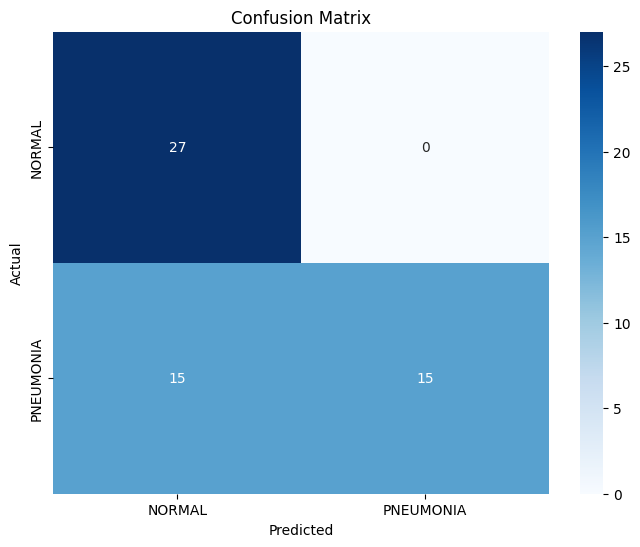

In [6]:
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()